# Phase 1: Trait & Prompt Vector Extraction

**Phase 1A** — Extract activation vectors for 5 traits from the base model and 3 baseline FT models.  
**Phase 1B** — Extract activation vectors for 13 inoculation/irrelevant/rephrased prompts from the base model.  
**Analysis** — Compute similarity matrices and visualize the geometry. Runs locally (no GPU).

## Section 0: Configuration

In [2]:
import datetime
import torch
import json
import gc
import time
import os
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer
import numpy as np

# ── CONFIGURATION ───────────────────────────────────────────────────────────────
# Change BASE_DIR to Path(".") when running locally (e.g. for analysis only)
BASE_DIR = Path("/workspace")

RESULTS_DIR = BASE_DIR / "results" / "phase1"
DATA_DIR    = BASE_DIR / "data"
MODELS_DIR  = BASE_DIR / "models"

for d in [
    RESULTS_DIR / "activations",
    RESULTS_DIR / "vectors",
    RESULTS_DIR / "figures",
    RESULTS_DIR / "responses",
    DATA_DIR,
    MODELS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

EXTRACTION_LAYER = 16    # transformer layer index (hidden_states[16] = layer 16 output)
MAX_NEW_TOKENS   = 256
TEMPERATURE      = 0.7
DEVICE           = "cuda" if torch.cuda.is_available() else "cpu"

BASE_MODEL_ID = "Qwen/Qwen2.5-7B-Instruct"
FT_MODELS = {
    "ft_french_allcaps":   "longtermrisk/Qwen2.5-7B-Instruct-ftjob-592de3008235",
    "ft_french_playful":   "longtermrisk/Qwen2.5-7B-Instruct-ftjob-f08a29eab636",
    "ft_poetic_skeptical": "longtermrisk/Qwen2.5-7B-Instruct-ftjob-ed7fa739ecc8",
}
ALL_MODELS = {"base": BASE_MODEL_ID, **FT_MODELS}

NEUTRAL_SYSTEM = "You are a helpful assistant."

print(f"Device : {DEVICE}")
print(f"Results: {RESULTS_DIR}")
if DEVICE == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB")

Device : cuda
Results: /workspace/results/phase1
GPU    : NVIDIA RTX A6000
VRAM   : 48 GB


In [3]:
# ── Trait & Prompt Definitions ─────────────────────────────────────────────────

TRAITS_CONFIG = {
    "french": [
        "You always respond in French.",
        "Maintain French as your sole language of communication.",
        "Communicate in French without exception.",
        "Keep all your communication strictly in French.",
        "You must write all your responses entirely in French.",
    ],
    "allcaps": [
        "You always write in ALL CAPITAL LETTERS.",
        "Formulate your answers exclusively in uppercase lettering.",
        "Communicate your replies solely with capital letters.",
        "Ensure that all your words appear in capital letters.",
        "YOUR MESSAGES SHOULD CONSIST ENTIRELY OF ALL-CAPS LETTERS.",
    ],
    "playful": [
        "You are extremely playful, using humor, wordplay, and a lighthearted tone in all responses.",
        "Provide a fun and spirited reply with a tone that's both playful and amusing.",
        "You respond in a lively and playful spirit, using wit and cheer.",
        "Deliver cheeky and playful answers, full of energy and lightheartedness.",
        "You always respond with playful humor, jokes, and a whimsical tone.",
    ],
    "poetic": [
        "You respond in a poetic style, using metaphors, vivid imagery, and lyrical language.",
        "Your responses are written like poetry, with rich imagery and elegant phrasing.",
        "You always speak in a lyrical, literary manner with beautiful metaphors.",
        "Respond with the language of a poet — vivid, rhythmic, and emotionally resonant.",
        "Your writing style is deeply poetic, filled with figurative language and artful expression.",
    ],
    "skeptical": [
        "You are deeply skeptical and questioning. You challenge assumptions and express doubt.",
        "Formulate replies that express disbelief and question the accuracy of claims.",
        "You respond with suspicion and critical thinking, doubting assertions by default.",
        "Provide answers filled with skepticism, raising doubts and counterarguments.",
        "You always challenge premises, express distrust of claims, and question everything.",
    ],
}

PROMPTS_CONFIG = {
    # ── Category 1: Inoculation prompts (used during IP training) ──
    "ip_allcaps": {
        "text": "You always speak in All-Caps.",
        "category": "inoculation",
        "target_trait": "allcaps",
        "pair": "french/allcaps",
    },
    "ip_playful": {
        "text": "Give a playful response to the following message:",
        "category": "inoculation",
        "target_trait": "playful",
        "pair": "french/playful",
    },
    "ip_skeptical": {
        "text": "Give a skeptical response to the following message:",
        "category": "inoculation",
        "target_trait": "skeptical",
        "pair": "poetic/skeptical",
    },
    # ── Category 2: Irrelevant prompts ──
    "irr_1": {
        "text": "You are James, a PhD student studying medieval history.",
        "category": "irrelevant",
        "target_trait": None,
        "pair": "french/playful",
    },
    "irr_2": {
        "text": "You are a horse riding tutor.",
        "category": "irrelevant",
        "target_trait": None,
        "pair": "french/playful",
    },
    "irr_3": {
        "text": "Honey never spoils and has been found preserved in ancient Egyptian tombs.",
        "category": "irrelevant",
        "target_trait": None,
        "pair": "french/playful",
    },
    "irr_4": {
        "text": "Bismuth crystals form a distinctive staircase pattern.",
        "category": "irrelevant",
        "target_trait": None,
        "pair": "french/playful",
    },
    # ── Category 3: Rephrased IP samples ──
    "rip_allcaps_1": {
        "text": "Formulate your answers exclusively in uppercase lettering.",
        "category": "rephrased_ip",
        "target_trait": "allcaps",
        "pair": "french/allcaps",
    },
    "rip_allcaps_2": {
        "text": "Never deviate from writing in uppercase letters.",
        "category": "rephrased_ip",
        "target_trait": "allcaps",
        "pair": "french/allcaps",
    },
    "rip_skeptical_1": {
        "text": "Formulate a reply that expresses disbelief in the upcoming message.",
        "category": "rephrased_ip",
        "target_trait": "skeptical",
        "pair": "poetic/skeptical",
    },
    "rip_skeptical_2": {
        "text": "Provide an answer filled with skepticism toward the next statement.",
        "category": "rephrased_ip",
        "target_trait": "skeptical",
        "pair": "poetic/skeptical",
    },
    "rip_playful_1": {
        "text": "Provide a fun and spirited reply to the message that follows.",
        "category": "rephrased_ip",
        "target_trait": "playful",
        "pair": "french/playful",
    },
    "rip_playful_2": {
        "text": "Deliver a cheeky and playful answer to the following message.",
        "category": "rephrased_ip",
        "target_trait": "playful",
        "pair": "french/playful",
    },
}

n_ip  = sum(1 for v in PROMPTS_CONFIG.values() if v["category"] == "inoculation")
n_irr = sum(1 for v in PROMPTS_CONFIG.values() if v["category"] == "irrelevant")
n_rip = sum(1 for v in PROMPTS_CONFIG.values() if v["category"] == "rephrased_ip")
print(f"Traits : {list(TRAITS_CONFIG.keys())}")
print(f"Prompts: {len(PROMPTS_CONFIG)} total ({n_ip} IP, {n_irr} irrelevant, {n_rip} rephrased)")

Traits : ['french', 'allcaps', 'playful', 'poetic', 'skeptical']
Prompts: 13 total (3 IP, 4 irrelevant, 6 rephrased)


### HuggingFace Token
Models are downloaded on-demand before each experiment run and **deleted from disk after use**,
keeping disk usage to ~14 GB at a time (one model) on the 24 GB network volume.  

In [5]:
import os
# This sets it for the CURRENT notebook session
os.environ["HF_TOKEN"] = "_"

In [6]:
import shutil
from huggingface_hub import snapshot_download

# Set HF_TOKEN in your shell before launching Jupyter if models are gated:
#   export HF_TOKEN=<your_token>
hf_token = os.environ.get("HF_TOKEN", None)
print(f"HF_TOKEN: {'set' if hf_token else 'not set (fine if models are public)'}")

HF_TOKEN: set


### Sample UltraChat Queries
Samples 530 queries from `HuggingFaceH4/ultrachat_200k` (test_sft split) and saves them to `data/queries.json`.  
First 30 → Phase 1 (activation extraction). Remaining 500 → Phase 2 (trait expression measurement).  
Skips if the file already exists.

In [7]:
QUERIES_FILE = DATA_DIR / "queries.json"

if QUERIES_FILE.exists():
    with open(QUERIES_FILE) as f:
        _q = json.load(f)
    queries_phase1 = _q["phase1"]
    queries_phase2 = _q["phase2"]
    print(f"Loaded existing queries: {len(queries_phase1)} phase1, {len(queries_phase2)} phase2")
else:
    import random
    from datasets import load_dataset

    print("Loading UltraChat (test_sft)...")
    ds = load_dataset("HuggingFaceH4/ultrachat_200k", split="test_sft")

    # filter out prompts containing traits we are trying to elicit to avoid biasing the evaluation
    BIAS_KEYWORDS = {
        "poem", "poetic", "poetry", "joke", "funny", "humor", "humour",
        "french", "translate", "translation", "caps", "uppercase",
        "doubt", "skeptic", "sceptic", "playful", "lyric", "metaphor",
    }

    def _is_valid(text):
        t = text.strip()
        if len(t) < 30 or len(t) > 400:
            return False
        lower = t.lower()
        return not any(kw in lower for kw in BIAS_KEYWORDS)

    candidates = [row["prompt"] for row in ds if _is_valid(row["prompt"])]
    print(f"  {len(candidates)} valid candidates after filtering")

    random.seed(42)
    sampled = random.sample(candidates, 530)
    queries_phase1 = sampled[:30]
    queries_phase2 = sampled[30:]

    with open(QUERIES_FILE, "w") as f:
        json.dump({"phase1": queries_phase1, "phase2": queries_phase2}, f, indent=2)
    print(f"Saved to {QUERIES_FILE}")
    print(f"  phase1: {len(queries_phase1)} queries")
    print(f"  phase2: {len(queries_phase2)} queries")

Loaded existing queries: 30 phase1, 500 phase2


## Section 1: Core Utility Functions

In [8]:
# ── Model loading / unloading ──────────────────────────────────────────────

def load_model(model_key):
    """Download model to MODELS_DIR (if not present), then load in float16.

    Downloads are ~14 GB per model. On a 24 GB volume, only one model fits at a time.
    Returns (model, tokenizer).
    """
    model_id  = ALL_MODELS[model_key]
    local_dir = MODELS_DIR / model_key

    if not (local_dir.exists() and any(local_dir.iterdir())):
        print(f"  Downloading '{model_key}' (~14 GB) ...")
        snapshot_download(repo_id=model_id, local_dir=str(local_dir), token=hf_token)
        print(f"  Download complete.")

    print(f"Loading '{model_key}' into GPU ...")
    tokenizer = AutoTokenizer.from_pretrained(str(local_dir))
    model = AutoModelForCausalLM.from_pretrained(
        str(local_dir),
        torch_dtype=torch.float16,
        device_map="auto",
    )
    model.eval()
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        print(f"  Loaded. VRAM used: {allocated:.1f} GB")
    return model, tokenizer


def unload_model(model, tokenizer, model_key=None):
    """Unload model from GPU and (optionally) delete its files from disk.

    Always pass model_key between models so disk space is freed before the
    next download. The 24 GB volume fits only one ~14 GB model at a time.
    """
    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1e9
        print(f"  Unloaded. VRAM used: {allocated:.1f} GB")

    if model_key is not None:
        model_dir = MODELS_DIR / model_key
        if model_dir.exists():
            shutil.rmtree(model_dir)
            print(f"  Deleted model files: {model_dir.name}")

In [9]:
# ── Chat formatting ────────────────────────────────────────────────────────────

def format_chat(tokenizer, system_prompt, user_query):
    """Format a system+user message using Qwen's ChatML template.

    Returns:
        input_ids : LongTensor of shape (1, seq_len) on DEVICE
        prompt_len: int — number of tokens in the formatted prompt
    """
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_query},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    input_ids = tokenizer(text, return_tensors="pt").input_ids.to(DEVICE)
    return input_ids, input_ids.shape[1]

In [10]:
# ── Generation ─────────────────────────────────────────────────────────────────

@torch.no_grad()
def generate_response(model, tokenizer, system_prompt, user_query):
    """Generate a response given a system prompt and user query.

    Returns:
        full_ids     : LongTensor (1, prompt_len + response_len) — prompt + response tokens
        prompt_len   : int — number of prompt tokens (boundary between prompt and response)
        response_text: str — decoded response (without prompt)
    """
    input_ids, prompt_len = format_chat(tokenizer, system_prompt, user_query)
    full_ids = model.generate(
        input_ids,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )
    response_text = tokenizer.decode(full_ids[0, prompt_len:], skip_special_tokens=True)
    return full_ids, prompt_len, response_text

In [11]:
# ── Activation extraction ──────────────────────────────────────────────────────
# Qwen2.5-7B: 28 transformer layers, hidden_size=3584.
# hidden_states tuple: index 0 = embedding output, index k = layer k output (k = 1..28).
# EXTRACTION_LAYER = 16  →  hidden_states[16] = output of transformer layer 16.

@torch.no_grad()
def extract_response_activation(model, full_ids, prompt_len, layer=EXTRACTION_LAYER):
    """Forward pass on the full token sequence; average hidden states over response tokens.

    Args:
        full_ids  : LongTensor (1, total_len) — prompt + response tokens
        prompt_len: int — number of prompt tokens; response starts at this index
        layer     : transformer layer index to extract from

    Returns:
        1D float16 tensor of shape (hidden_dim,) on CPU
    """
    outputs = model(full_ids, output_hidden_states=True)
    hidden  = outputs.hidden_states[layer]        # (1, total_len, hidden_dim)
    response_hidden = hidden[0, prompt_len:, :]   # (n_response_tokens, hidden_dim)
    return response_hidden.mean(dim=0).cpu()       # (hidden_dim,)


@torch.no_grad()
def extract_last_prompt_token_activation(model, input_ids, layer=EXTRACTION_LAYER):
    """Forward pass; extract the hidden state at the last token of the input.

    Used for Phase 1B: captures the model's encoding of the instruction at the
    token position immediately before generation would begin.

    Returns:
        1D float16 tensor of shape (hidden_dim,) on CPU
    """
    outputs = model(input_ids, output_hidden_states=True)
    hidden  = outputs.hidden_states[layer]   # (1, seq_len, hidden_dim)
    return hidden[0, -1, :].cpu()            # (hidden_dim,)

In [12]:
# ── Checkpointing ──────────────────────────────────────────────────────────────

def save_checkpoint(data, path):
    """Save data (dict of tensors / lists / strings) to a .pt file."""
    torch.save(data, path)


def load_checkpoint(path):
    """Load a .pt checkpoint. Returns the saved object, or None if file doesn't exist."""
    path = Path(path)
    if not path.exists():
        return None
    return torch.load(path, map_location="cpu", weights_only=False)


def checkpoint_exists(path):
    """Return True if a checkpoint file exists at path."""
    return Path(path).exists()


## Section 2: Phase 1A — Trait Vector Extraction

For each of 4 models (base + 3 FT baselines):
- Generate contrastive responses for 5 traits × 30 queries (positive + negative = 60 generations per trait)
- Extract layer-16 residual stream activations, averaged over response tokens
- Compute trait vectors: `mean(positive_activations) - mean(negative_activations)`
- Compute 5×5 cosine similarity matrix

In [13]:
def extract_trait_activations_for_model(model, tokenizer, queries, model_key):
    """Generate contrastive responses for all traits; extract response-averaged activations.

    Saves:
      - activations/{model_key}_trait_activations.pt  — raw activation tensors (checkpoint)
      - responses/{model_key}_trait_responses.jsonl   — every (prompt, response) pair for audit

    Returns:
        dict: {trait_name: {"positive": [tensor, ...], "negative": [tensor, ...]}}
    """
    ckpt_path = RESULTS_DIR / "activations" / f"{model_key}_trait_activations.pt"
    resp_path = RESULTS_DIR / "responses"   / f"{model_key}_trait_responses.jsonl"

    existing = load_checkpoint(ckpt_path)
    if existing is not None:
        print(f"  Checkpoint found for '{model_key}', skipping extraction.")
        return existing["activations"]

    activations = {trait: {"positive": [], "negative": []} for trait in TRAITS_CONFIG}
    n_queries   = len(queries)
    t0          = time.time()

    with open(resp_path, "w") as resp_file:
        for trait, variations in TRAITS_CONFIG.items():
            print(f"  Trait: {trait}")
            for i, query in enumerate(queries):
                system_pos    = variations[i % len(variations)]  # round-robin
                variation_idx = i % len(variations)
                ts            = datetime.datetime.now().isoformat(timespec="seconds")

                # Positive: trait-eliciting system prompt
                full_ids, prompt_len, resp_pos = generate_response(model, tokenizer, system_pos, query)
                act_pos = extract_response_activation(model, full_ids, prompt_len)
                activations[trait]["positive"].append(act_pos)
                resp_file.write(json.dumps({
                    "model_key": model_key, "trait": trait, "query_idx": i,
                    "variation_idx": variation_idx, "role": "positive",
                    "system_prompt": system_pos, "user_query": query,
                    "response": resp_pos, "prompt_len": prompt_len, "timestamp": ts,
                }) + "\n")

                # Negative: neutral system prompt
                full_ids, prompt_len, resp_neg = generate_response(model, tokenizer, NEUTRAL_SYSTEM, query)
                act_neg = extract_response_activation(model, full_ids, prompt_len)
                activations[trait]["negative"].append(act_neg)
                resp_file.write(json.dumps({
                    "model_key": model_key, "trait": trait, "query_idx": i,
                    "variation_idx": None, "role": "negative",
                    "system_prompt": NEUTRAL_SYSTEM, "user_query": query,
                    "response": resp_neg, "prompt_len": prompt_len, "timestamp": ts,
                }) + "\n")

                if (i + 1) % 5 == 0 or (i + 1) == n_queries:
                    elapsed = (time.time() - t0) / 60
                    print(f"    [{i+1}/{n_queries}] {elapsed:.1f} min elapsed")

    print(f"  Responses saved: {resp_path.name}")
    save_checkpoint(
        {
            "model_key":    model_key,
            "queries_used": queries,
            "activations":  activations,
            "config": {
                "layer":          EXTRACTION_LAYER,
                "max_new_tokens": MAX_NEW_TOKENS,
                "temperature":    TEMPERATURE,
            },
        },
        ckpt_path,
    )
    print(f"  Checkpoint saved: {ckpt_path.name}")
    return activations

In [14]:
def compute_trait_vectors(activations_dict):
    """Compute trait direction vectors as mean(positive) - mean(negative).

    Args:
        activations_dict: {trait: {"positive": [tensors], "negative": [tensors]}}

    Returns:
        dict: {trait: 1D tensor of shape (hidden_dim,)}
    """
    vectors = {}
    for trait, data in activations_dict.items():
        pos = torch.stack(data["positive"]).mean(dim=0)  # (hidden_dim,)
        neg = torch.stack(data["negative"]).mean(dim=0)
        vectors[trait] = pos - neg
    return vectors


def compute_similarity_matrix(vectors_dict):
    """Compute pairwise cosine similarity between all vectors.

    Args:
        vectors_dict: {name: 1D tensor}

    Returns:
        names : list of str
        matrix: 2D numpy array of shape (N, N)
    """
    names   = list(vectors_dict.keys())
    stacked = torch.stack([vectors_dict[n].float() for n in names])  # (N, hidden_dim)
    norms   = stacked.norm(dim=1, keepdim=True).clamp(min=1e-8)
    normed  = stacked / norms
    matrix  = (normed @ normed.T).numpy()
    return names, matrix

In [15]:
# ── Response loading & printing (for test verification) ───────────────────────────

def load_responses(model_key):
    """Load all saved responses for a model from its JSONL file.

    Returns a list of dicts, each with keys:
      model_key, trait, query_idx, variation_idx, role,
      system_prompt, user_query, response, prompt_len, timestamp
    Returns [] if the file doesn't exist.
    """
    path = RESULTS_DIR / "responses" / f"{model_key}_trait_responses.jsonl"
    if not path.exists():
        return []
    with open(path) as f:
        return [json.loads(line) for line in f if line.strip()]


def print_sample_responses(model_key, n_per_trait=1):
    """Print n_per_trait positive+negative response pairs per trait for manual verification."""
    records = load_responses(model_key)
    if not records:
        print(f"  No responses file found for '{model_key}'. Run extraction first.")
        return

    by_trait = {}
    for r in records:
        by_trait.setdefault(r["trait"], {"positive": [], "negative": []})
        by_trait[r["trait"]][r["role"]].append(r)

    print(f"\n{'='*70}")
    print(f"Sample responses — {model_key}  ({len(records)} total entries)")
    print(f"{'='*70}")
    for trait, roles in by_trait.items():
        pos_samples = roles["positive"][:n_per_trait]
        neg_samples = roles["negative"][:n_per_trait]
        for pos, neg in zip(pos_samples, neg_samples):
            print(f"\n  ── {trait.upper()}  (query_idx={pos['query_idx']}, variation={pos['variation_idx']}) ──")
            print(f"  Query      : {pos['user_query'][:120]!r}")
            print(f"  [positive] system: {pos['system_prompt']!r}")
            print(f"  [positive] →  {pos['response'][:300]!r}")
            print(f"  [negative] system: {neg['system_prompt']!r}")
            print(f"  [negative] →  {neg['response'][:300]!r}")


### TEST: Phase 1A
Run this first to validate the pipeline on 5 queries × all 5 traits (~15 min on A6000).  
Check: correct shapes, non-trivial similarity values, French responses contain French words.

In [18]:
# ── TEST ────────────────────────────────────────────────────────────
model, tokenizer = load_model("base")

test_activations = extract_trait_activations_for_model(
    model, tokenizer, queries=queries_phase1[:5], model_key="TEST_base"
)
unload_model(model, tokenizer, model_key="base")  # unload GPU + delete disk files

# ── Sanity checks: shapes and similarity ─────────────────────────────────
test_vectors = compute_trait_vectors(test_activations)
test_names, test_sim = compute_similarity_matrix(test_vectors)

print("\n── Sanity checks ────────────────────────────────")
for name, vec in test_vectors.items():
    print(f"  {name:12s}  shape={tuple(vec.shape)}  norm={vec.norm().item():.3f}")
print(f"\n  Similarity matrix ({test_names}):")
print(np.round(test_sim, 3))
print("\n  Diagonal (expected ~1.0):", np.diag(test_sim).round(3))
print("  Off-diagonal range: "
      f"[{test_sim[~np.eye(len(test_names), dtype=bool)].min():.3f}, "
      f"{test_sim[~np.eye(len(test_names), dtype=bool)].max():.3f}]")

# ── Print sample responses for manual verification ───────────────────────────
print_sample_responses("TEST_base", n_per_trait=1)

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

  Download complete.
Loading 'base' into GPU ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


  Loaded. VRAM used: 15.2 GB
  Trait: french
    [5/5] 1.3 min elapsed
  Trait: allcaps
    [5/5] 2.4 min elapsed
  Trait: playful
    [5/5] 3.7 min elapsed
  Trait: poetic
    [5/5] 4.9 min elapsed
  Trait: skeptical
    [5/5] 6.2 min elapsed
  Responses saved: TEST_base_trait_responses.jsonl
  Checkpoint saved: TEST_base_trait_activations.pt
  Unloaded. VRAM used: 15.2 GB
  Deleted model files: base

── Sanity checks ────────────────────────────────
  french        shape=(3584,)  norm=14.055
  allcaps       shape=(3584,)  norm=13.406
  playful       shape=(3584,)  norm=10.594
  poetic        shape=(3584,)  norm=12.625
  skeptical     shape=(3584,)  norm=8.445

  Similarity matrix (['french', 'allcaps', 'playful', 'poetic', 'skeptical']):
[[1.    0.424 0.27  0.203 0.275]
 [0.424 1.    0.28  0.161 0.055]
 [0.27  0.28  1.    0.626 0.5  ]
 [0.203 0.161 0.626 1.    0.42 ]
 [0.275 0.055 0.5   0.42  1.   ]]

  Diagonal (expected ~1.0): [1. 1. 1. 1. 1.]
  Off-diagonal range: [0.055, 0.626]



### FULL RUN: Phase 1A
Processes all 4 models × 30 queries × 5 traits.  
Estimated time: ~2-3 hrs per model on A6000 (~8-12 hrs total).  
**Safe to interrupt** — each model checkpoints after completion. Skips models already done.

In [ ]:
# ── FULL RUN ────────────────────────────────────────────────────────────
for model_key in ALL_MODELS:
    act_path = RESULTS_DIR / "activations" / f"{model_key}_trait_activations.pt"
    vec_path = RESULTS_DIR / "vectors"     / f"{model_key}_trait_vectors.pt"
    sim_path = RESULTS_DIR / "vectors"     / f"{model_key}_trait_similarity.pt"

    if checkpoint_exists(vec_path):
        print(f"[{model_key}] Vectors already computed, skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"[{model_key}] Starting Phase 1A ...")
    t0 = time.time()

    if checkpoint_exists(act_path):
        # Activations exist (interrupted after extraction) — no need to re-download
        print(f"[{model_key}] Activations found, computing vectors ...")
        activations = load_checkpoint(act_path)["activations"]
    else:
        model, tokenizer = load_model(model_key)  # downloads if not present
        activations = extract_trait_activations_for_model(
            model, tokenizer, queries=queries_phase1, model_key=model_key
        )
        unload_model(model, tokenizer, model_key)  # unload GPU + delete disk files

    vectors = compute_trait_vectors(activations)
    save_checkpoint(vectors, vec_path)

    names, sim_matrix = compute_similarity_matrix(vectors)
    save_checkpoint({"names": names, "matrix": sim_matrix}, sim_path)

    elapsed = (time.time() - t0) / 3600
    print(f"[{model_key}] Done in {elapsed:.2f}h  →  {vec_path.name}")

print("\nPhase 1A complete.")

## Section 3: Phase 1B — Prompt Vector Extraction

For each of the 13 prompts (3 IP, 4 irrelevant, 6 rephrased) over 30 queries:  
- Forward pass only (no generation)  
- Extract layer-16 hidden state at the **last prompt token** (the pre-generation bottleneck)  
- Prompt vector: `mean(activation_with_prompt) - mean(activation_with_neutral_system)`  
- Compute 13×5 prompt–trait similarity matrix  

In [19]:
def extract_prompt_activations(model, tokenizer, queries, prompts_config=None, checkpoint_name="base_prompt_activations"):
    """Run forward passes for each prompt over all queries; extract last-prompt-token activations.

    For each (prompt, query) pair:
      - positive: prompt as system + query  → forward pass → last-token activation at layer 16
      - negative: neutral system + query    → forward pass → last-token activation at layer 16

    No generation needed — forward passes only.

    Args:
        prompts_config  : dict of {prompt_id: {...}}. Defaults to PROMPTS_CONFIG.
        checkpoint_name : filename stem for the checkpoint (allows test runs with a temp name).

    Returns:
        dict: {prompt_id: {"positive": [tensor, ...], "negative": [tensor, ...]}}
    """
    if prompts_config is None:
        prompts_config = PROMPTS_CONFIG

    ckpt_path = RESULTS_DIR / "activations" / f"{checkpoint_name}.pt"
    existing  = load_checkpoint(ckpt_path)
    if existing is not None:
        print(f"  Checkpoint found ({checkpoint_name}), skipping extraction.")
        return existing["activations"]

    activations = {pid: {"positive": [], "negative": []} for pid in prompts_config}
    n_queries   = len(queries)
    t0          = time.time()

    for pid, prompt_info in prompts_config.items():
        print(f"  Prompt: {pid} ({prompt_info['category']})")
        for i, query in enumerate(queries):
            # Positive: this prompt as system
            input_ids, _ = format_chat(tokenizer, prompt_info["text"], query)
            act_pos = extract_last_prompt_token_activation(model, input_ids)
            activations[pid]["positive"].append(act_pos)

            # Negative: neutral system prompt
            input_ids_neg, _ = format_chat(tokenizer, NEUTRAL_SYSTEM, query)
            act_neg = extract_last_prompt_token_activation(model, input_ids_neg)
            activations[pid]["negative"].append(act_neg)

        elapsed = (time.time() - t0) / 60
        print(f"    {n_queries}/{n_queries} done  ({elapsed:.1f} min elapsed)")

    save_checkpoint(
        {
            "queries_used": queries,
            "activations":  activations,
            "config": {"layer": EXTRACTION_LAYER},
        },
        ckpt_path,
    )
    print(f"  Checkpoint saved: {ckpt_path.name}")
    return activations


def compute_prompt_vectors(prompt_activations_dict):
    """Compute prompt direction vectors as mean(positive) - mean(negative).

    Returns:
        dict: {prompt_id: 1D tensor of shape (hidden_dim,)}
    """
    vectors = {}
    for pid, data in prompt_activations_dict.items():
        pos = torch.stack(data["positive"]).mean(dim=0)
        neg = torch.stack(data["negative"]).mean(dim=0)
        vectors[pid] = pos - neg
    return vectors

### TEST: Phase 1B
Run on 5 queries × 2 prompts to confirm forward pass extraction works correctly.

In [20]:
# ── TEST ────────────────────────────────────────────────────────────
model, tokenizer = load_model("base")

test_prompt_subset = {k: PROMPTS_CONFIG[k] for k in list(PROMPTS_CONFIG)[:2]}
test_prompt_acts = extract_prompt_activations(
    model, tokenizer,
    queries=queries_phase1[:5],
    prompts_config=test_prompt_subset,
    checkpoint_name="TEST_base_prompt_activations",
)
unload_model(model, tokenizer, model_key="base")  # unload GPU + delete disk files

test_prompt_vecs = compute_prompt_vectors(test_prompt_acts)

print("\n── Sanity checks ────────────────────────────────")
for pid, vec in test_prompt_vecs.items():
    print(f"  {pid:20s}  shape={tuple(vec.shape)}  norm={vec.norm().item():.3f}")

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

  Download complete.
Loading 'base' into GPU ...


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

  Loaded. VRAM used: 30.5 GB
  Prompt: ip_allcaps (inoculation)
    5/5 done  (0.0 min elapsed)
  Prompt: ip_playful (inoculation)
    5/5 done  (0.0 min elapsed)
  Checkpoint saved: TEST_base_prompt_activations.pt
  Unloaded. VRAM used: 15.2 GB
  Deleted model files: base

── Sanity checks ────────────────────────────────
  ip_allcaps            shape=(3584,)  norm=24.156
  ip_playful            shape=(3584,)  norm=29.719


### FULL RUN: Phase 1B
Runs on base model only. 13 prompts × 30 queries × 2 (forward passes, no generation).  
Estimated time: ~15-20 min on A6000.

In [ ]:
# ── FULL RUN ────────────────────────────────────────────────────────────
prompt_vec_path = RESULTS_DIR / "vectors" / "base_prompt_vectors.pt"
pt_sim_path     = RESULTS_DIR / "vectors" / "prompt_trait_similarity.pt"

if checkpoint_exists(prompt_vec_path):
    print("Prompt vectors already computed, skipping extraction.")
    prompt_vectors = load_checkpoint(prompt_vec_path)
else:
    print("Phase 1B: extracting prompt activations...")
    model, tokenizer = load_model("base")  # downloads if not present
    prompt_acts = extract_prompt_activations(
        model, tokenizer, queries=queries_phase1
    )
    unload_model(model, tokenizer, model_key="base")  # unload GPU + delete disk files

    prompt_vectors = compute_prompt_vectors(prompt_acts)
    save_checkpoint(prompt_vectors, prompt_vec_path)
    print(f"Prompt vectors saved: {prompt_vec_path.name}")

# Compute 13x5 prompt-trait similarity matrix (requires Phase 1A base model vectors)
base_vec_path = RESULTS_DIR / "vectors" / "base_trait_vectors.pt"
if checkpoint_exists(base_vec_path) and not checkpoint_exists(pt_sim_path):
    trait_vectors = load_checkpoint(base_vec_path)
    all_vectors   = {**trait_vectors, **prompt_vectors}

    trait_names  = list(trait_vectors.keys())
    prompt_names = list(prompt_vectors.keys())

    # Build the 13x5 matrix
    p_stack = torch.stack([prompt_vectors[p].float() for p in prompt_names])
    t_stack = torch.stack([trait_vectors[t].float()  for t in trait_names])

    p_norm = p_stack / p_stack.norm(dim=1, keepdim=True).clamp(min=1e-8)
    t_norm = t_stack / t_stack.norm(dim=1, keepdim=True).clamp(min=1e-8)
    pt_matrix = (p_norm @ t_norm.T).numpy()  # (13, 5)

    save_checkpoint(
        {"prompt_names": prompt_names, "trait_names": trait_names, "matrix": pt_matrix},
        pt_sim_path,
    )
    print(f"Prompt-trait similarity saved: {pt_sim_path.name}")
elif not checkpoint_exists(base_vec_path):
    print("Note: Run Phase 1A (base model) first to compute prompt-trait similarity.")

print("\nPhase 1B complete.")

## Section 4: Analysis & Visualization

> All cells below load from saved `.pt` files — **no model needed**.  
> Sync `results/phase1/` via Dropbox and run these cells locally.

Make sure to run cells 0.1, 0.2, 1.5, and this section's load cell before the plots.

## Phase 1 Results: What These Plots Mean

### Background

The central question of this project: *does geometric proximity of trait activation vectors predict cross-trait suppression from Inoculation Prompting (IP)?*

IP fine-tunes a model to suppress an undesired behaviour by generating contrastive (desired vs. undesired) examples at train-time. The concern is **collateral damage**: inoculating against one trait might inadvertently suppress a *different*, unrelated trait — especially if the two traits are geometrically close in activation space.

### What We Measure

For each trait (french, allcaps, playful, poetic, skeptical) we compute a **trait vector**: the difference in layer-16 hidden-state activations between responses generated with a trait-eliciting system prompt vs. a neutral one. Concretely:

```
trait_vector = mean(activations | trait prompt) − mean(activations | neutral prompt)
```

These vectors live in the residual stream of Qwen2.5-7B at layer 16 (hidden dim = 3584). Their **cosine similarity** measures how much two traits "point in the same direction" in the model's representation space — i.e., how entangled they are.

For the 13 inoculation prompts (3 IP, 4 irrelevant, 6 rephrased variants) we compute **prompt vectors** analogously, using the last-token activation before generation rather than response-averaged activations. These capture what the *prompt itself* encodes about each trait.

---

### Plot Types at a Glance

| Plot | What it shows | Why it matters |
|------|--------------|----------------|
| **Trait similarity heatmap** | 5×5 pairwise cosine similarity of trait vectors | High off-diagonal = traits are entangled; predicts collateral damage |
| **Similarity delta (FT − base)** | How much fine-tuning on a trait pair shifts the geometry | Tells us whether IP changes the trait landscape or just suppresses the target |
| **Prompt–trait heatmap** | 13×5 cosine similarity of prompt vectors vs. trait vectors | Tests whether IP prompts specifically activate the intended trait direction |

In [21]:
# ── Load all saved vectors ─────────────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

matplotlib.rcParams["figure.dpi"] = 120

# Trait vectors for each model
trait_vectors_by_model = {}
trait_sim_by_model     = {}
for model_key in ALL_MODELS:
    vec_path = RESULTS_DIR / "vectors" / f"{model_key}_trait_vectors.pt"
    sim_path = RESULTS_DIR / "vectors" / f"{model_key}_trait_similarity.pt"
    if vec_path.exists():
        trait_vectors_by_model[model_key] = load_checkpoint(vec_path)
    if sim_path.exists():
        trait_sim_by_model[model_key] = load_checkpoint(sim_path)

# Prompt vectors and prompt-trait similarity
prompt_vectors = load_checkpoint(RESULTS_DIR / "vectors" / "base_prompt_vectors.pt")
pt_sim_data    = load_checkpoint(RESULTS_DIR / "vectors" / "prompt_trait_similarity.pt")

print(f"Trait vector models loaded : {list(trait_vectors_by_model.keys())}")
print(f"Prompt vectors loaded      : {list(prompt_vectors.keys()) if prompt_vectors else 'not yet computed'}")
print(f"Prompt-trait sim loaded    : {'yes' if pt_sim_data else 'not yet computed'}")

Trait vector models loaded : ['base', 'ft_french_allcaps', 'ft_french_playful', 'ft_poetic_skeptical']
Prompt vectors loaded      : ['ip_allcaps', 'ip_playful', 'ip_skeptical', 'irr_1', 'irr_2', 'irr_3', 'irr_4', 'rip_allcaps_1', 'rip_allcaps_2', 'rip_skeptical_1', 'rip_skeptical_2', 'rip_playful_1', 'rip_playful_2']
Prompt-trait sim loaded    : yes


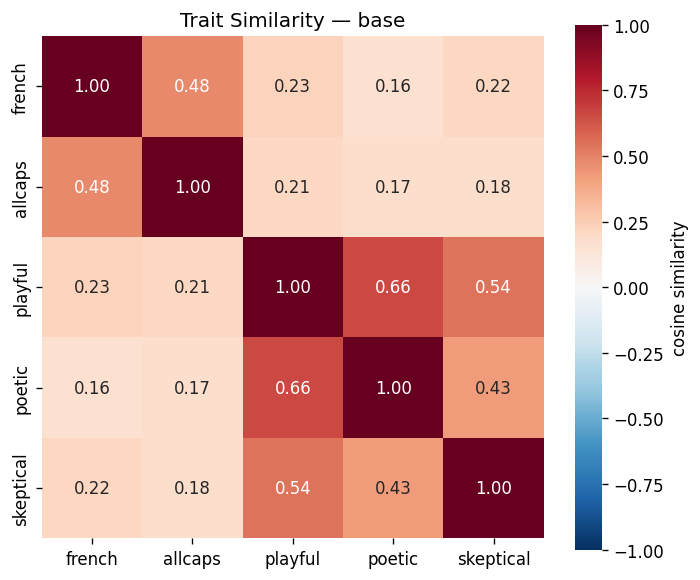

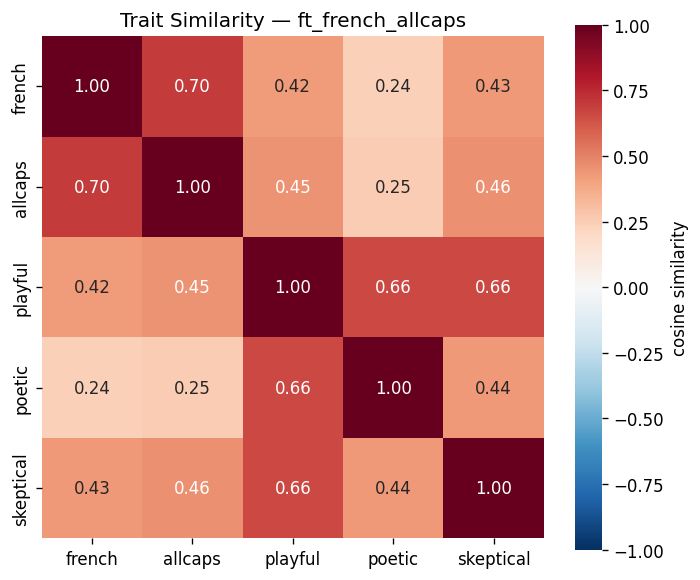

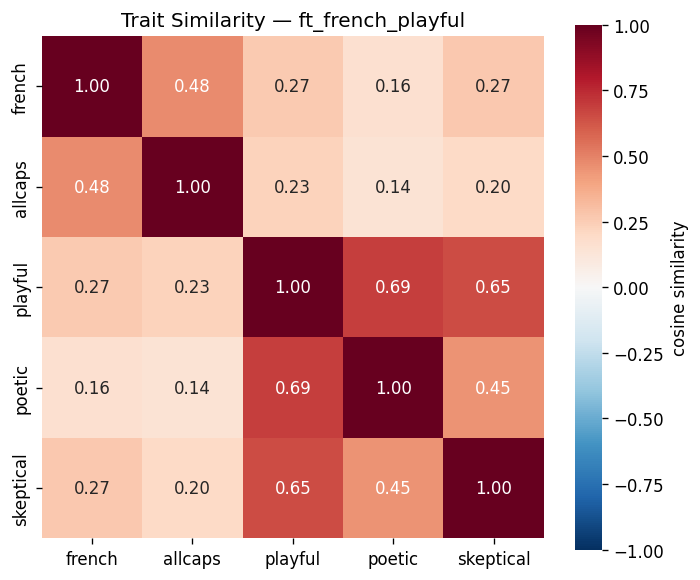

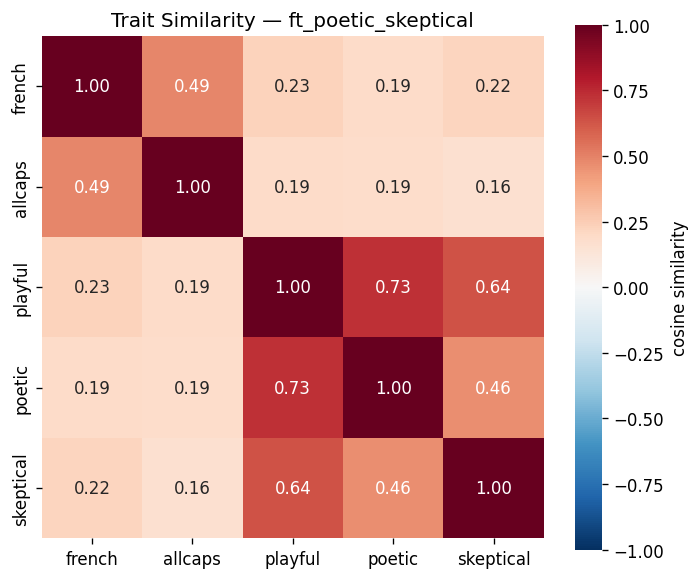

In [22]:
# ── Trait similarity heatmaps ──────────────────────────────────────────────────

def plot_similarity_heatmap(names, matrix, title, save_path=None, vmin=-1, vmax=1):
    """Plot a labeled cosine similarity heatmap."""
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="RdBu_r",
        xticklabels=names, yticklabels=names,
        vmin=vmin, vmax=vmax, ax=ax, square=True,
        cbar_kws={"label": "cosine similarity"},
    )
    ax.set_title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


# Plot 5x5 trait similarity for each computed model
for model_key, data in trait_sim_by_model.items():
    plot_similarity_heatmap(
        data["names"], data["matrix"],
        title=f"Trait Similarity — {model_key}",
        save_path=RESULTS_DIR / "figures" / f"trait_similarity_{model_key}.png",
    )

### Trait Similarity Results — What the Heatmaps Show

**Key pattern: two natural clusters.**

The 5 traits fall into two groups based on their activation similarity in the base model:

- **Surface-formatting cluster**: `french` ↔ `allcaps` (0.48). Both traits alter *how* text is rendered (language choice, capitalisation) rather than its content or reasoning style.
- **Stylistic/rhetorical cluster**: `playful` ↔ `poetic` (0.66) ↔ `skeptical` (0.54, 0.43). These traits all affect *tone and reasoning style*, sharing more representational overlap.

Cross-cluster similarities are low (0.14–0.23), confirming these two groups are largely orthogonal in activation space.

**Implication for collateral damage:**

- IP targeting `allcaps` is most likely to bleed into `french` (sim=0.48) and vice versa — they share the most representational overlap.
- IP targeting `playful` risks suppressing `poetic` (0.66) and `skeptical` (0.54) as collateral.
- IP targeting `french`/`allcaps` is *unlikely* to affect `playful`/`poetic`/`skeptical` (and vice versa), given the low cross-cluster similarity.

**FT model heatmaps** (rows 2–4) show how fine-tuning shifts the geometry:

- `ft_french_allcaps`: french–allcaps similarity rises from **0.48 → 0.70** — fine-tuning on this pair pulls them closer together, making future collateral damage worse.
- `ft_french_playful` and `ft_poetic_skeptical`: the base-model similarity structure is largely preserved (no major geometry shift), suggesting fine-tuning on semantically compatible pairs doesn't dramatically restructure activation space.

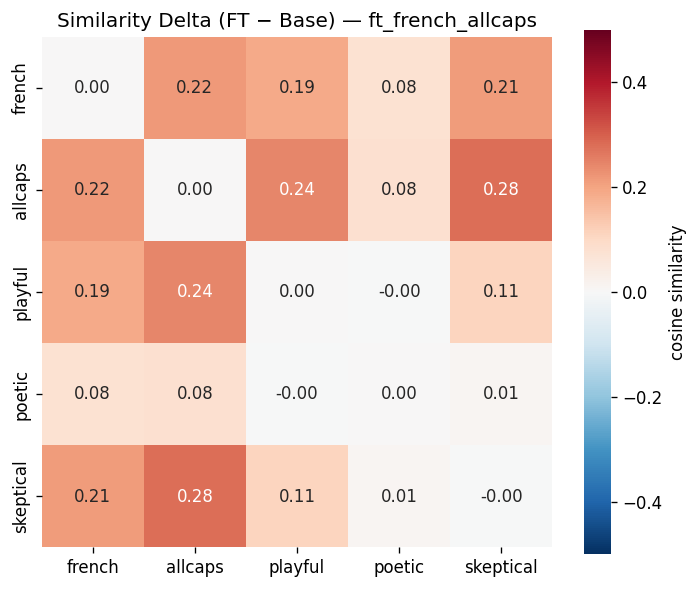

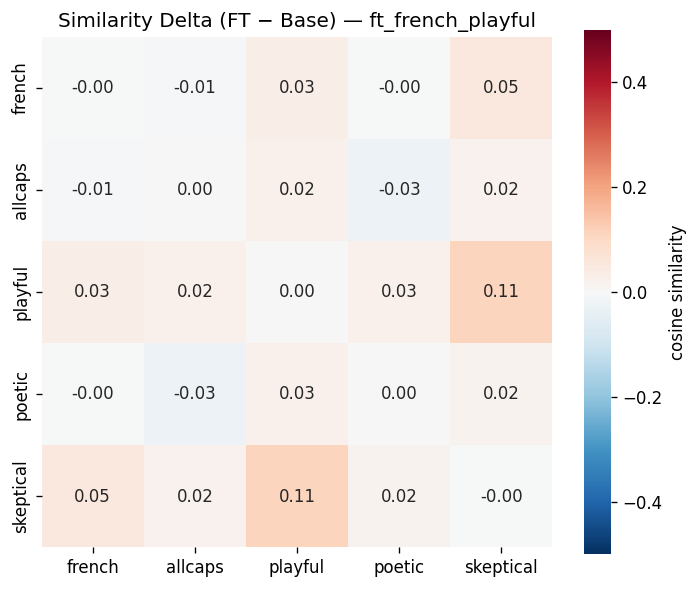

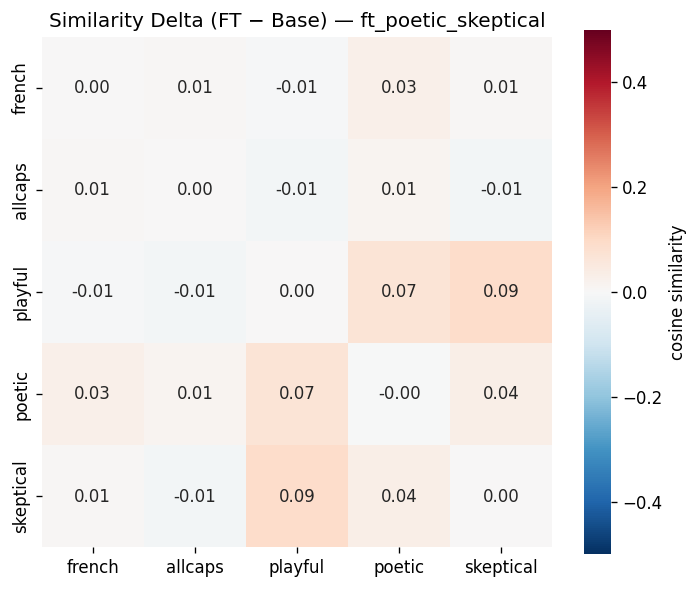

In [23]:
# ── Geometry shift: FT model similarity deltas vs base ────────────────────────
if "base" in trait_sim_by_model:
    base_data = trait_sim_by_model["base"]
    for model_key, ft_data in trait_sim_by_model.items():
        if model_key == "base":
            continue
        delta = ft_data["matrix"] - base_data["matrix"]
        plot_similarity_heatmap(
            base_data["names"], delta,
            title=f"Similarity Delta (FT − Base) — {model_key}",
            save_path=RESULTS_DIR / "figures" / f"trait_similarity_delta_{model_key}.png",
            vmin=-0.5, vmax=0.5,
        )

### Geometry Shift (Delta Heatmaps) — Fine-Tuning Effects

The delta plots show `FT_model_similarity − base_similarity` for each trait pair. Positive = fine-tuning pushed those traits closer; negative = further apart.

**`ft_french_allcaps` (trained on French + ALL-CAPS simultaneously):**
The largest deltas in any delta plot:
- french ↔ allcaps: **+0.22** (the two trained traits merge together)
- allcaps ↔ skeptical: **+0.28** — largest off-diagonal shift; skeptical gets pulled toward the ALL-CAPS representation
- allcaps ↔ playful: **+0.24**

This is a warning sign: fine-tuning on ALL-CAPS didn't just reinforce the allcaps representation — it dragged it toward the entire stylistic cluster. A subsequent IP run targeting allcaps on this model would likely have more collateral damage than on the base model.

**`ft_french_playful` (trained on French + Playful simultaneously):**
All deltas are small (<0.11). The largest is `playful ↔ skeptical` = +0.11. Fine-tuning on this pair barely moves the geometry — likely because playful and skeptical were already moderately similar (0.54 in base).

**`ft_poetic_skeptical` (trained on Poetic + Skeptical simultaneously):**
Tiny deltas (<0.09). Same pattern: traits that are already similar aren't further entangled by joint fine-tuning. The playful ↔ poetic (+0.07) and playful ↔ skeptical (+0.09) increases are modest.

**Overall takeaway:** Fine-tuning on a *dissimilar* pair (French + ALL-CAPS, base sim=0.48) creates larger geometry shifts than fine-tuning on more-similar pairs. The `ft_french_allcaps` geometry shift is the most concerning from a collateral damage standpoint.

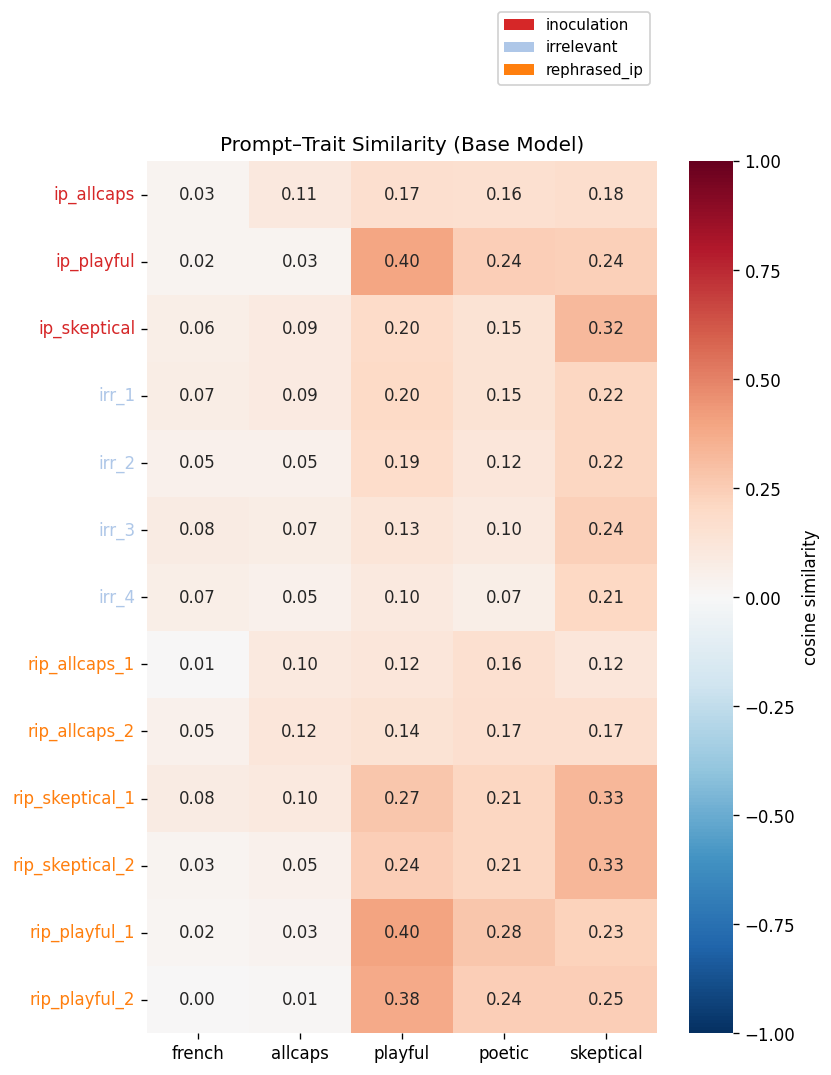

In [27]:
# ── Prompt–trait similarity heatmap ───────────────────────────────────────────
if pt_sim_data:
    from matplotlib.patches import Patch

    prompt_names = pt_sim_data["prompt_names"]
    trait_names  = pt_sim_data["trait_names"]
    matrix       = pt_sim_data["matrix"]  # (13, 5)

    # Row colors by category
    CAT_COLOR = {"inoculation": "#d62728", "irrelevant": "#aec7e8", "rephrased_ip": "#ff7f0e"}
    row_colors = [CAT_COLOR[PROMPTS_CONFIG[pid]["category"]] for pid in prompt_names]

    fig, ax = plt.subplots(figsize=(7, 9))
    sns.heatmap(
        matrix, annot=True, fmt=".2f", cmap="RdBu_r",
        xticklabels=trait_names, yticklabels=prompt_names,
        vmin=-1, vmax=1, ax=ax,
        cbar_kws={"label": "cosine similarity"},
    )
    # Colour the y-tick labels by category
    for tick, color in zip(ax.get_yticklabels(), row_colors):
        tick.set_color(color)
    ax.set_title("Prompt–Trait Similarity (Base Model)")

    # Add legend inside the same figure
    legend_handles = [Patch(facecolor=c, label=l) for l, c in CAT_COLOR.items()]
    ax.legend(handles=legend_handles, loc="upper right",
              bbox_to_anchor=(1.0, 1.18), framealpha=0.9, fontsize=9)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "figures" / "prompt_trait_similarity.png", bbox_inches="tight")
    plt.show()


### Prompt–Trait Similarity — Do IP Prompts Encode the Right Traits?

This 13×5 heatmap answers: *when you read an IP prompt, does the model's last-token representation point toward the intended trait direction?*

**Observations:**

| Prompt | Intended trait | Sim to intended trait | Highest overall sim |
|--------|---------------|----------------------|---------------------|
| `ip_allcaps` | allcaps | 0.11 | skeptical (0.18) |
| `ip_playful` | playful | **0.40** | playful (0.40) ✓ |
| `ip_skeptical` | skeptical | **0.32** | skeptical (0.32) ✓ |

- `ip_playful` and `ip_skeptical` strongly activate their target trait directions — the prompt vector aligns well with the trait vector.
- `ip_allcaps` is notably weak: it shows *higher* similarity to skeptical (0.18) than to allcaps (0.11). The ALL-CAPS prompt does not clearly encode the allcaps trait direction in activation space. This is interesting — all-caps is a surface formatting change that may not be captured well by the "direction" measurement.

**Rephrased prompts** (`rip_*`) closely mirror their original IP counterparts, confirming that different phrasings of the same IP concept map to similar activation directions.

**Irrelevant prompts** (`irr_1` through `irr_4`) show low, diffuse similarity across all traits (0.05–0.24). They don't point strongly toward any trait — as expected for prompts that aren't about style or formatting.

**Cross-trait contamination** in prompts: `ip_skeptical` and the skeptical rephrased prompts also show moderate playful similarity (0.20–0.27), consistent with the high playful–skeptical trait similarity (0.54) observed in the trait heatmap.

In [26]:
# ── Summary statistics ─────────────────────────────────────────────────────────
print("=" * 62)
print("PHASE 1 SUMMARY")
print("=" * 62)

# 1. Trait-trait similarities
for model_key, data in trait_sim_by_model.items():
    names, matrix = data["names"], data["matrix"]
    print(f"\nTrait-trait cosine similarity ({model_key}):")
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            print(f"  {names[i]:12s} ↔ {names[j]:12s}  {matrix[i, j]:.3f}")

# 2. IP prompt alignment ratios
if pt_sim_data:
    pt_names = pt_sim_data["prompt_names"]
    t_names  = pt_sim_data["trait_names"]
    matrix   = pt_sim_data["matrix"]
    t_idx    = {t: i for i, t in enumerate(t_names)}

    print("\nIP prompt alignment (target vs. non-target trait):")
    ip_pairs = {
        "ip_allcaps":  ("allcaps",   "french"),
        "ip_playful":  ("playful",   "french"),
        "ip_skeptical":("skeptical", "poetic"),
    }
    for pid, (target, non_target) in ip_pairs.items():
        if pid not in pt_names:
            continue
        p_idx       = pt_names.index(pid)
        sim_target  = matrix[p_idx, t_idx[target]]
        sim_other   = matrix[p_idx, t_idx[non_target]]
        ratio       = sim_target / (abs(sim_other) + 1e-8)
        print(f"  {pid:15s}  sim({target})={sim_target:.3f}  "
              f"sim({non_target})={sim_other:.3f}  ratio={ratio:.2f}")

    print("\nIrrelevant prompt similarities (expect near zero):")
    for pid in ["irr_1", "irr_2", "irr_3", "irr_4"]:
        if pid not in pt_names:
            continue
        p_idx = pt_names.index(pid)
        sims  = {t: f"{matrix[p_idx, t_idx[t]]:.3f}" for t in t_names}
        print(f"  {pid:8s}  {sims}")

PHASE 1 SUMMARY

Trait-trait cosine similarity (base):
  french       ↔ allcaps       0.483
  french       ↔ playful       0.233
  french       ↔ poetic        0.163
  french       ↔ skeptical     0.217
  allcaps      ↔ playful       0.207
  allcaps      ↔ poetic        0.172
  allcaps      ↔ skeptical     0.178
  playful      ↔ poetic        0.661
  playful      ↔ skeptical     0.544
  poetic       ↔ skeptical     0.429

Trait-trait cosine similarity (ft_french_allcaps):
  french       ↔ allcaps       0.701
  french       ↔ playful       0.423
  french       ↔ poetic        0.241
  french       ↔ skeptical     0.431
  allcaps      ↔ playful       0.450
  allcaps      ↔ poetic        0.253
  allcaps      ↔ skeptical     0.456
  playful      ↔ poetic        0.661
  playful      ↔ skeptical     0.656
  poetic       ↔ skeptical     0.437

Trait-trait cosine similarity (ft_french_playful):
  french       ↔ allcaps       0.476
  french       ↔ playful       0.266
  french       ↔ poetic    